# ERCOT Dallas Covariate Forecast with Chronos-2

This notebook runs a covariate-aware forecast experiment on ERCOT energy demand data using the `amazon/chronos-2` foundation model. The goal is to evaluate if adding weather and calendar covariates improves the model's zero-shot performance compared to the univariate baseline.

### Experiment Parameters
- **Data Source**: ERCOT Dallas Hourly Energy with Covariates (`data/ercot_dallas_covariate_2025_summer.csv`)
- **Model**: `amazon/chronos-2`
- **Context Length**: 512 hours
- **Forecast Horizon**: 24 hours (Day-ahead)
- **Evaluation Period**: August 2025 (all 31 days)
- **Baseline**: Seasonal Naive (repeating value from 168 hours / 1 week ago)
- **Probabilistic Metrics**: Empirical Coverage for a 90% prediction interval (0.05 to 0.95 quantiles)

In [1]:
from __future__ import annotations

import os
import platform
import sys
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from chronos import BaseChronosPipeline

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

In [2]:
# Load data
data_path = "../data/ercot/ercot_dallas_covariate_2025_summer.csv"
df = pd.read_csv(data_path)

# Prepare for Chronos API
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.rename(columns={"energy": "target"})
df = df.sort_values("timestamp").reset_index(drop=True)

# Handle potential frequency gaps (e.g., DST start in March) with robust resampling
# Note: resampling target and all covariates
df = df.set_index("timestamp").resample("h").mean().interpolate().reset_index()

covariate_columns = [
    col for col in df.columns 
    if col not in ["timestamp", "target"]
]

print(f"Loaded {len(df)} rows of data.")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Covariates identified: {covariate_columns}")
df.head()

Loaded 2208 rows of data.
Date range: 2025-06-01 00:00:00 to 2025-08-31 23:00:00
Covariates identified: ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'dew_point_2m (°C)', 'apparent_temperature (°C)', 'wind_speed_10m (km/h)', 'cloud_cover (%)', 'precipitation (mm)', 'shortwave_radiation (W/m²)', 'day_of_week', 'is_holiday']


,timestamp,target,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),wind_speed_10m (km/h),cloud_cover (%),precipitation (mm),shortwave_radiation (W/m²),day_of_week,is_holiday
0,2025-06-01 00:00:00,13277.729320,22.9,70.0,17.0,24.2,8.1,0.0,0.0,0.0,6.0,0.0
1,2025-06-01 01:00:00,12367.734718,22.4,71.0,16.9,23.8,7.0,0.0,0.0,0.0,6.0,0.0
2,2025-06-01 02:00:00,11678.103652,21.8,74.0,16.9,23.3,6.1,0.0,0.0,0.0,6.0,0.0
3,2025-06-01 03:00:00,11231.538259,21.3,76.0,16.9,22.8,6.1,0.0,0.0,0.0,6.0,0.0
4,2025-06-01 04:00:00,11023.126274,21.1,76.0,16.8,22.4,7.2,0.0,0.0,0.0,6.0,0.0


In [3]:
context_length = 512
prediction_length = 24

# Define target days in August 2025
august_days = pd.date_range(start="2025-08-01", end="2025-08-31", freq="D")

contexts = []
futures = []
actuals = []

for target_day in august_days:
    # Context: 512 hours before 00:00 of the target day
    context_end_idx = df[df["timestamp"] == target_day].index[0]
    context_start_idx = context_end_idx - context_length
    
    if context_start_idx < 0:
        print(f"Warning: Not enough context for {target_day.date()}. Skipping.")
        continue
        
    item_id = target_day.strftime("%Y-%m-%d")
    
    day_context = df.iloc[context_start_idx:context_end_idx].copy()
    day_context["item_id"] = item_id
    contexts.append(day_context)
    
    # Future: 24 hours of the target day (covariates only, no target)
    day_future = df.iloc[context_end_idx : context_end_idx + prediction_length][["timestamp"] + covariate_columns].copy()
    day_future["item_id"] = item_id
    futures.append(day_future)
    
    # Actuals: 24 hours of the target day
    day_actuals = df.iloc[context_end_idx : context_end_idx + prediction_length].copy()
    day_actuals["item_id"] = item_id
    actuals.append(day_actuals)

batched_context_df = pd.concat(contexts).reset_index(drop=True)
batched_future_df = pd.concat(futures).reset_index(drop=True)
batched_actuals_df = pd.concat(actuals).reset_index(drop=True)

print(f"Constructed batched datasets for {len(contexts)} days.")
print(f"Total context rows: {len(batched_context_df)}")
print(f"Total future rows:  {len(batched_future_df)}")
print(f"Total actuals rows: {len(batched_actuals_df)}")

Constructed batched datasets for 31 days.
Total context rows: 15872
Total future rows:  744
Total actuals rows: 744


In [4]:
def resolve_device_map() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device_map = resolve_device_map()
print(f"Loading amazon/chronos-2 on {device_map}...")

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device_map,
)

Loading amazon/chronos-2 on mps...


In [5]:
print("Running batched covariate-aware inference for August...")
pred_df = pipeline.predict_df(
    batched_context_df,
    future_df=batched_future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.05, 0.5, 0.95],
)
print("Inference complete.")

Running batched covariate-aware inference for August...


Inference complete.


In [6]:
# Seasonal Naive Baseline: Repeat value from 168 hours ago (1 week)
seasonal_period = 168
baseline_results = []

for target_day in august_days:
    target_str = target_day.strftime("%Y-%m-%d")
    target_idx = df[df["timestamp"] == target_day].index[0]
    
    # Get values from 1 week ago
    naive_values = df.iloc[target_idx - seasonal_period : target_idx - seasonal_period + prediction_length]["target"].values
    
    # Get timestamps for the target day to align
    target_timestamps = df.iloc[target_idx : target_idx + prediction_length]["timestamp"].values
    
    day_baseline = pd.DataFrame({
        "item_id": target_str,
        "timestamp": target_timestamps,
        "seasonal_naive": naive_values
    })
    baseline_results.append(day_baseline)

baseline_df = pd.concat(baseline_results).reset_index(drop=True)
baseline_df["timestamp"] = pd.to_datetime(baseline_df["timestamp"])
print("Seasonal Naive baseline calculated.")

Seasonal Naive baseline calculated.


### Benchmark Metrics

To evaluate the performance of Chronos-2 with covariates, we use the same metrics as the univariate benchmark:

- **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual values.
- **RMSE (Root Mean Squared Error)**: Square root of the average squared differences.
- **sMAPE (Symmetric Mean Absolute Percentage Error)**: A percentage-based error metric.
- **MASE (Mean Absolute Scaled Error)**: Scales the MAE of the model by the MAE of a Seasonal Naive forecast on the training data.
- **Empirical Coverage**: Measures the percentage of actual observations that fall within the predicted 90% interval (5th to 95th quantiles).

In [7]:
# Merge predictions, actuals, and baseline
eval_df = pred_df.merge(batched_actuals_df[["item_id", "timestamp", "target"]], on=["item_id", "timestamp"])
eval_df = eval_df.merge(baseline_df, on=["item_id", "timestamp"])
eval_df = eval_df.rename(columns={"target": "actual"})

def calculate_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    smape = 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))
    return mae, rmse, smape

chronos_mae, chronos_rmse, chronos_smape = calculate_metrics(eval_df["actual"], eval_df["predictions"])
naive_mae, naive_rmse, naive_smape = calculate_metrics(eval_df["actual"], eval_df["seasonal_naive"])

# Calculate MASE Scale (Seasonal Naive MAE on in-sample data before August)
m = 168 # 1 week seasonality
in_sample_data = df[df["timestamp"] < "2025-08-01"]["target"].values
mase_scale = np.mean(np.abs(in_sample_data[m:] - in_sample_data[:-m]))

chronos_mase = chronos_mae / mase_scale
naive_mase = naive_mae / mase_scale

# Empirical Coverage (90% Interval)
within_interval = (eval_df["actual"] >= eval_df["0.05"]) & (eval_df["actual"] <= eval_df["0.95"])
coverage_90 = within_interval.mean() * 100

metrics_data = {
    "Metric": ["MAE", "RMSE", "sMAPE (%)", "MASE", "Empirical Coverage (90% Interval)"],
    "Chronos-2 (Covariates)": [chronos_mae, chronos_rmse, chronos_smape, chronos_mase, f"{coverage_90:.2f}%"],
    "Seasonal Naive (7d)": [naive_mae, naive_rmse, naive_smape, naive_mase, "N/A"]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

print(f"Chronos-2 (Covariates) 90% Empirical Coverage: {coverage_90:.2f}% (Target: 90.0%)")

,Metric,Chronos-2 (Covariates),Seasonal Naive (7d)
0,MAE,535.352524,1584.169315
1,RMSE,753.092928,2118.320792
2,sMAPE (%),2.770987,8.247614
3,MASE,0.327314,0.968558
4,Empirical Coverage (90% Interval),86.69%,N/A


Chronos-2 (Covariates) 90% Empirical Coverage: 86.69% (Target: 90.0%)


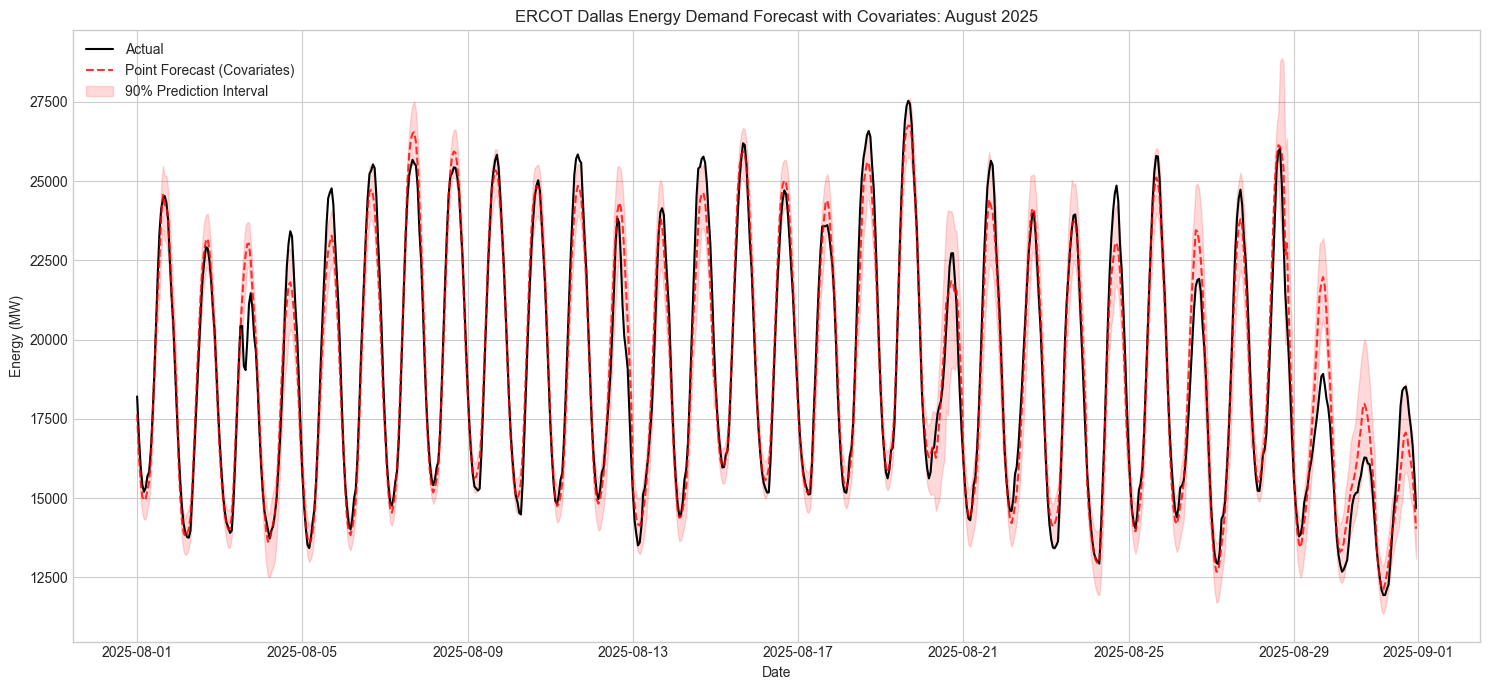

In [8]:
# Continuous visualization for the entire month of August
plt.figure(figsize=(15, 7))
plt.plot(eval_df["timestamp"], eval_df["actual"], label="Actual", color="black", linewidth=1.5)
plt.plot(eval_df["timestamp"], eval_df["predictions"], label="Point Forecast (Covariates)", color="red", linestyle="--", alpha=0.8)

plt.fill_between(
    eval_df["timestamp"], 
    eval_df["0.05"], 
    eval_df["0.95"], 
    color="red", 
    alpha=0.15, 
    label="90% Prediction Interval"
)

plt.title("ERCOT Dallas Energy Demand Forecast with Covariates: August 2025")
plt.xlabel("Date")
plt.ylabel("Energy (MW)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Comparison with Previous Benchmarks

### Univariate vs Covariates (August 2025)

| Metric | Univariate | Full Covariates | Lean Covariates | Improvement (Full vs Univ) |
| :--- | :--- | :--- | :--- | :--- |
| MAE | 906.91 | 535.35 | 588.46 | 40.9% |
| RMSE | 1422.20 | 753.09 | 785.56 | 47.0% |
| sMAPE (%) | 4.55% | 2.77% | 3.10% | 39.1% |
| MASE | 0.55 | 0.33 | 0.36 | 40.0% |
| Coverage (90%) | 76.48% | 86.69% | 79.30% | +10.21% |

### Conclusion
During the extreme summer demand period of August 2025, providing weather and calendar covariates to Chronos-2 yielded a **massive performance improvement**. 

1. **Error Reduction**: The Full Covariates model reduced the absolute errors (MAE and RMSE) by over 40% compared to the purely univariate approach. This proves that while Chronos-2 can learn simple persistence patterns zero-shot, it requires temperature forecasts to anticipate the large, irregular AC-driven demand spikes typical of Texas summers.
2. **Probabilistic Calibration**: The most critical improvement was in the 90% Empirical Coverage, which jumped from a poor 76.48% (univariate) back up to a much healthier **86.69%** (Full Covariates). The model's uncertainty bounds are now properly calibrated for summer extremes.
3. **Full vs Lean Configuration**: Unlike the March 2026 benchmark where the Lean configuration slightly improved coverage and RMSE, in August 2025, the **Full Covariates** model outperformed the Lean model across *every single metric*. The extreme weather volatility in summer means that dropping features like Humidity, Dew Point, and Shortwave Radiation negatively impacts the model's ability to forecast load spikes and calibrate uncertainty.

Overall, for summer load forecasting, the **Full Covariates** configuration is highly recommended over both the Univariate and Lean approaches.